Session 5 - Forecasting

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing

df = pd.read_csv("../data/cleaned/online_retail_cleaned.csv")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df.shape)
df.head()

(397884, 13)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,InvoiceDay,InvoiceHour,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12-01,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12-01,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,8,Wednesday


Creating monthly revenue to use in forcasting model

In [3]:
monthly_revenue = df.set_index("InvoiceDate").resample("ME")["Revenue"].sum()
monthly_revenue

InvoiceDate
2010-12-31     572713.890
2011-01-31     569445.040
2011-02-28     447137.350
2011-03-31     595500.760
2011-04-30     469200.361
2011-05-31     678594.560
2011-06-30     661213.690
2011-07-31     600091.011
2011-08-31     645343.900
2011-09-30     952838.382
2011-10-31    1039318.790
2011-11-30    1161817.380
2011-12-31     518192.790
Freq: ME, Name: Revenue, dtype: float64

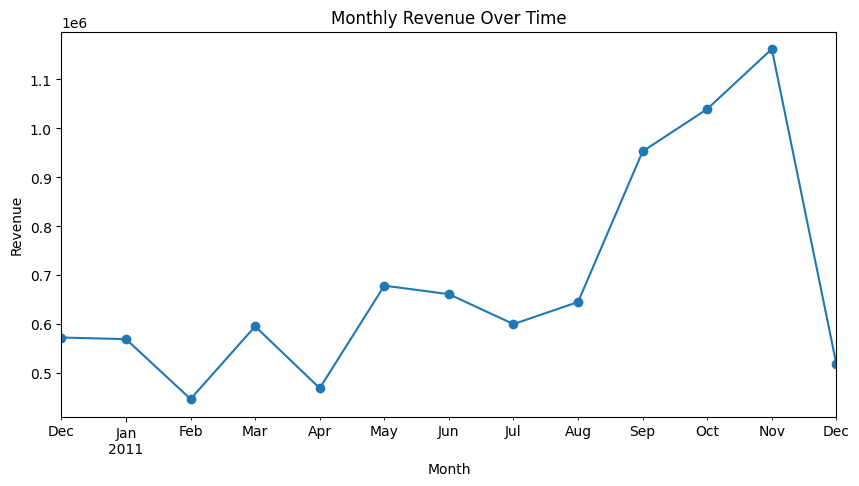

In [4]:
monthly_revenue.plot(figsize=(10,5), marker="o")
plt.title("Monthly Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

**Observations**
- Monthly revenue shows noticeable variation over time
- Revenue appears to increase toward the later months of the year indicating a seasonal shopping behavior

------------------------------------------------------------------------------------------------------

Baseline forecasting model

In [5]:
train = monthly_revenue.iloc[:-3]
test = monthly_revenue.iloc[-3:]

print("Train length:", len(train))
print("Test length:", len(test))
print(test)

Train length: 10
Test length: 3
InvoiceDate
2011-10-31    1039318.79
2011-11-30    1161817.38
2011-12-31     518192.79
Freq: ME, Name: Revenue, dtype: float64


In [6]:
naive_forecast = pd.Series([train.iloc[-1]] * len(test), index=test.index)

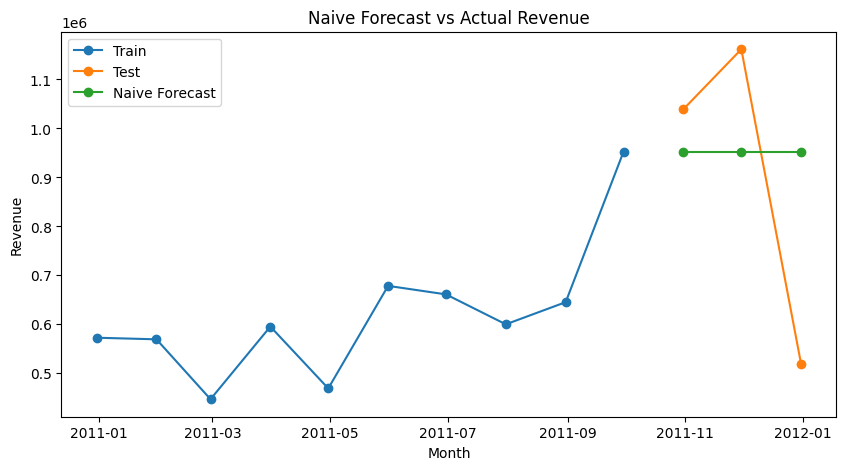

In [7]:
plt.figure(figsize=(10,5))
plt.plot(train.index, train.values, label="Train", marker="o")
plt.plot(test.index, test.values, label="Test", marker="o")
plt.plot(naive_forecast.index, naive_forecast.values, label="Naive Forecast", marker="o")
plt.title("Naive Forecast vs Actual Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.show()

In [8]:
naive_mae = mean_absolute_error(test, naive_forecast)
naive_rmse = np.sqrt(mean_squared_error(test, naive_forecast))

print("Naive MAE:", round(naive_mae, 2))
print("Naive RMSE:", round(naive_rmse, 2))

Naive MAE: 243368.33
Naive RMSE: 282882.7


------------------------------------------------------------------------------------------------------

Building a better model using exponential smoothing from statsmodels

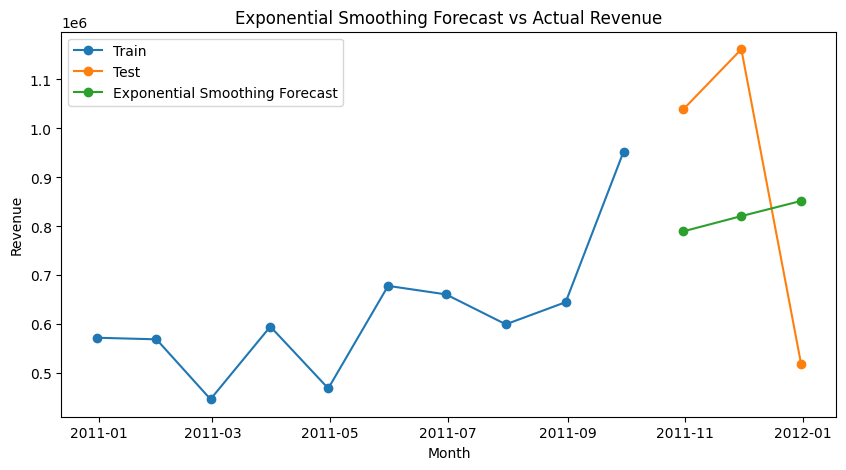

In [10]:
model = ExponentialSmoothing(train, trend="add", seasonal=None)
fit = model.fit()
forecast = fit.forecast(len(test))

plt.figure(figsize=(10,5))
plt.plot(train.index, train.values, label="Train", marker="o")
plt.plot(test.index, test.values, label="Test", marker="o")
plt.plot(forecast.index, forecast.values, label="Exponential Smoothing Forecast", marker="o")
plt.title("Exponential Smoothing Forecast vs Actual Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.show()

In [11]:
model_mae = mean_absolute_error(test, forecast)
model_rmse = np.sqrt(mean_squared_error(test, forecast))

print("Exponential Smoothing MAE:", round(model_mae, 2))
print("Exponential Smoothing RMSE:", round(model_rmse, 2))

Exponential Smoothing MAE: 307999.28
Exponential Smoothing RMSE: 310794.13


------------------------------------------------------------------------------------------------------

Comparing the models

In [12]:
comparison = pd.DataFrame({
    "Model": ["Naive Forecast", "Exponential Smoothing"],
    "MAE": [naive_mae, model_mae],
    "RMSE": [naive_rmse, model_rmse]
})

comparison

,Model,MAE,RMSE
0,Naive Forecast,243368.332667,282882.704325
1,Exponential Smoothing,307999.279362,310794.129997


Two forecasting approaches were tested: a naive forecast and an exponential smoothing model.
The naive forecast produced lower error on both evaluation metrics.

Because the naive forecast had lower MAE and RMSE, it was selected as the better-performing model for this dataset. This suggests that the more complex exponential smoothing model did not improve forecast accuracy over the simple baseline, likely due to the short time span and volatility in the monthly revenue series.

------------------------------------------------------------------------------------------------------

**Final Forecasting**

In [14]:
# Final naive forecast using the full monthly revenue series

future_naive_forecast = pd.Series(
    [monthly_revenue.iloc[-1]] * 3,
    index=pd.date_range(
        start=monthly_revenue.index[-1] + pd.offsets.MonthEnd(1),
        periods=3,
        freq="ME"
    )
)

print(future_naive_forecast)

2012-01-31    518192.79
2012-02-29    518192.79
2012-03-31    518192.79
Freq: ME, dtype: float64


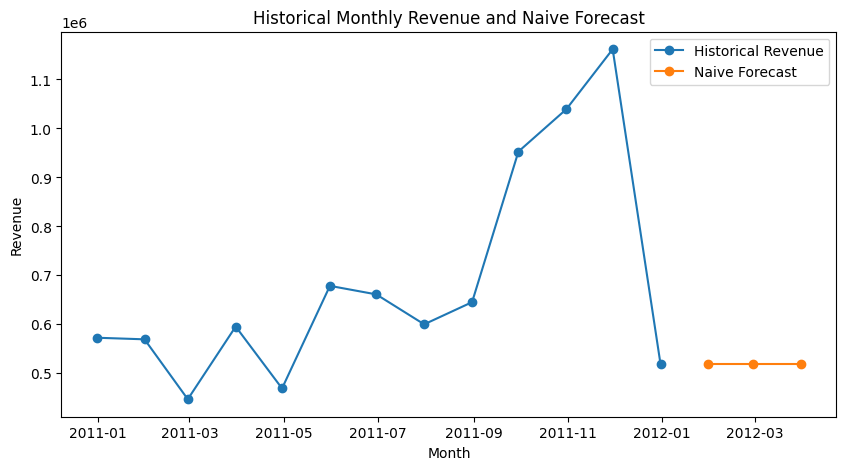

In [15]:
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue.index, monthly_revenue.values, label="Historical Revenue", marker="o")
plt.plot(future_naive_forecast.index, future_naive_forecast.values, label="Naive Forecast", marker="o")
plt.title("Historical Monthly Revenue and Naive Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.show()

**Final Results**

Two forecasting approaches were tested:

1. Naive forecast
2. Exponential smoothing

The naive forecast performed better on the test set based on both MAE and RMSE.

- Naive MAE: 243,368.33
- Naive RMSE: 282,882.70
- Exponential Smoothing MAE: 307,999.28
- Exponential Smoothing RMSE: 310,794.13

Since the naive forecast produced lower error on both evaluation metrics, it was selected as the final forecasting method for this dataset.

This suggests that the more complex exponential smoothing model did not improve predictive accuracy over the simple baseline. A likely reason is that the monthly revenue series is short and volatile, with a noticeable holiday spike followed by a sharp drop.

**Forecacsting Limitations**
The forecasting analysis is limited by the short time span of the available monthly data. Because the dataset covers only about one year of monthly revenue, the models may not fully capture recurring seasonal patterns. Forecast results should therefore be interpreted cautiously.